# Linear Regression & Classification
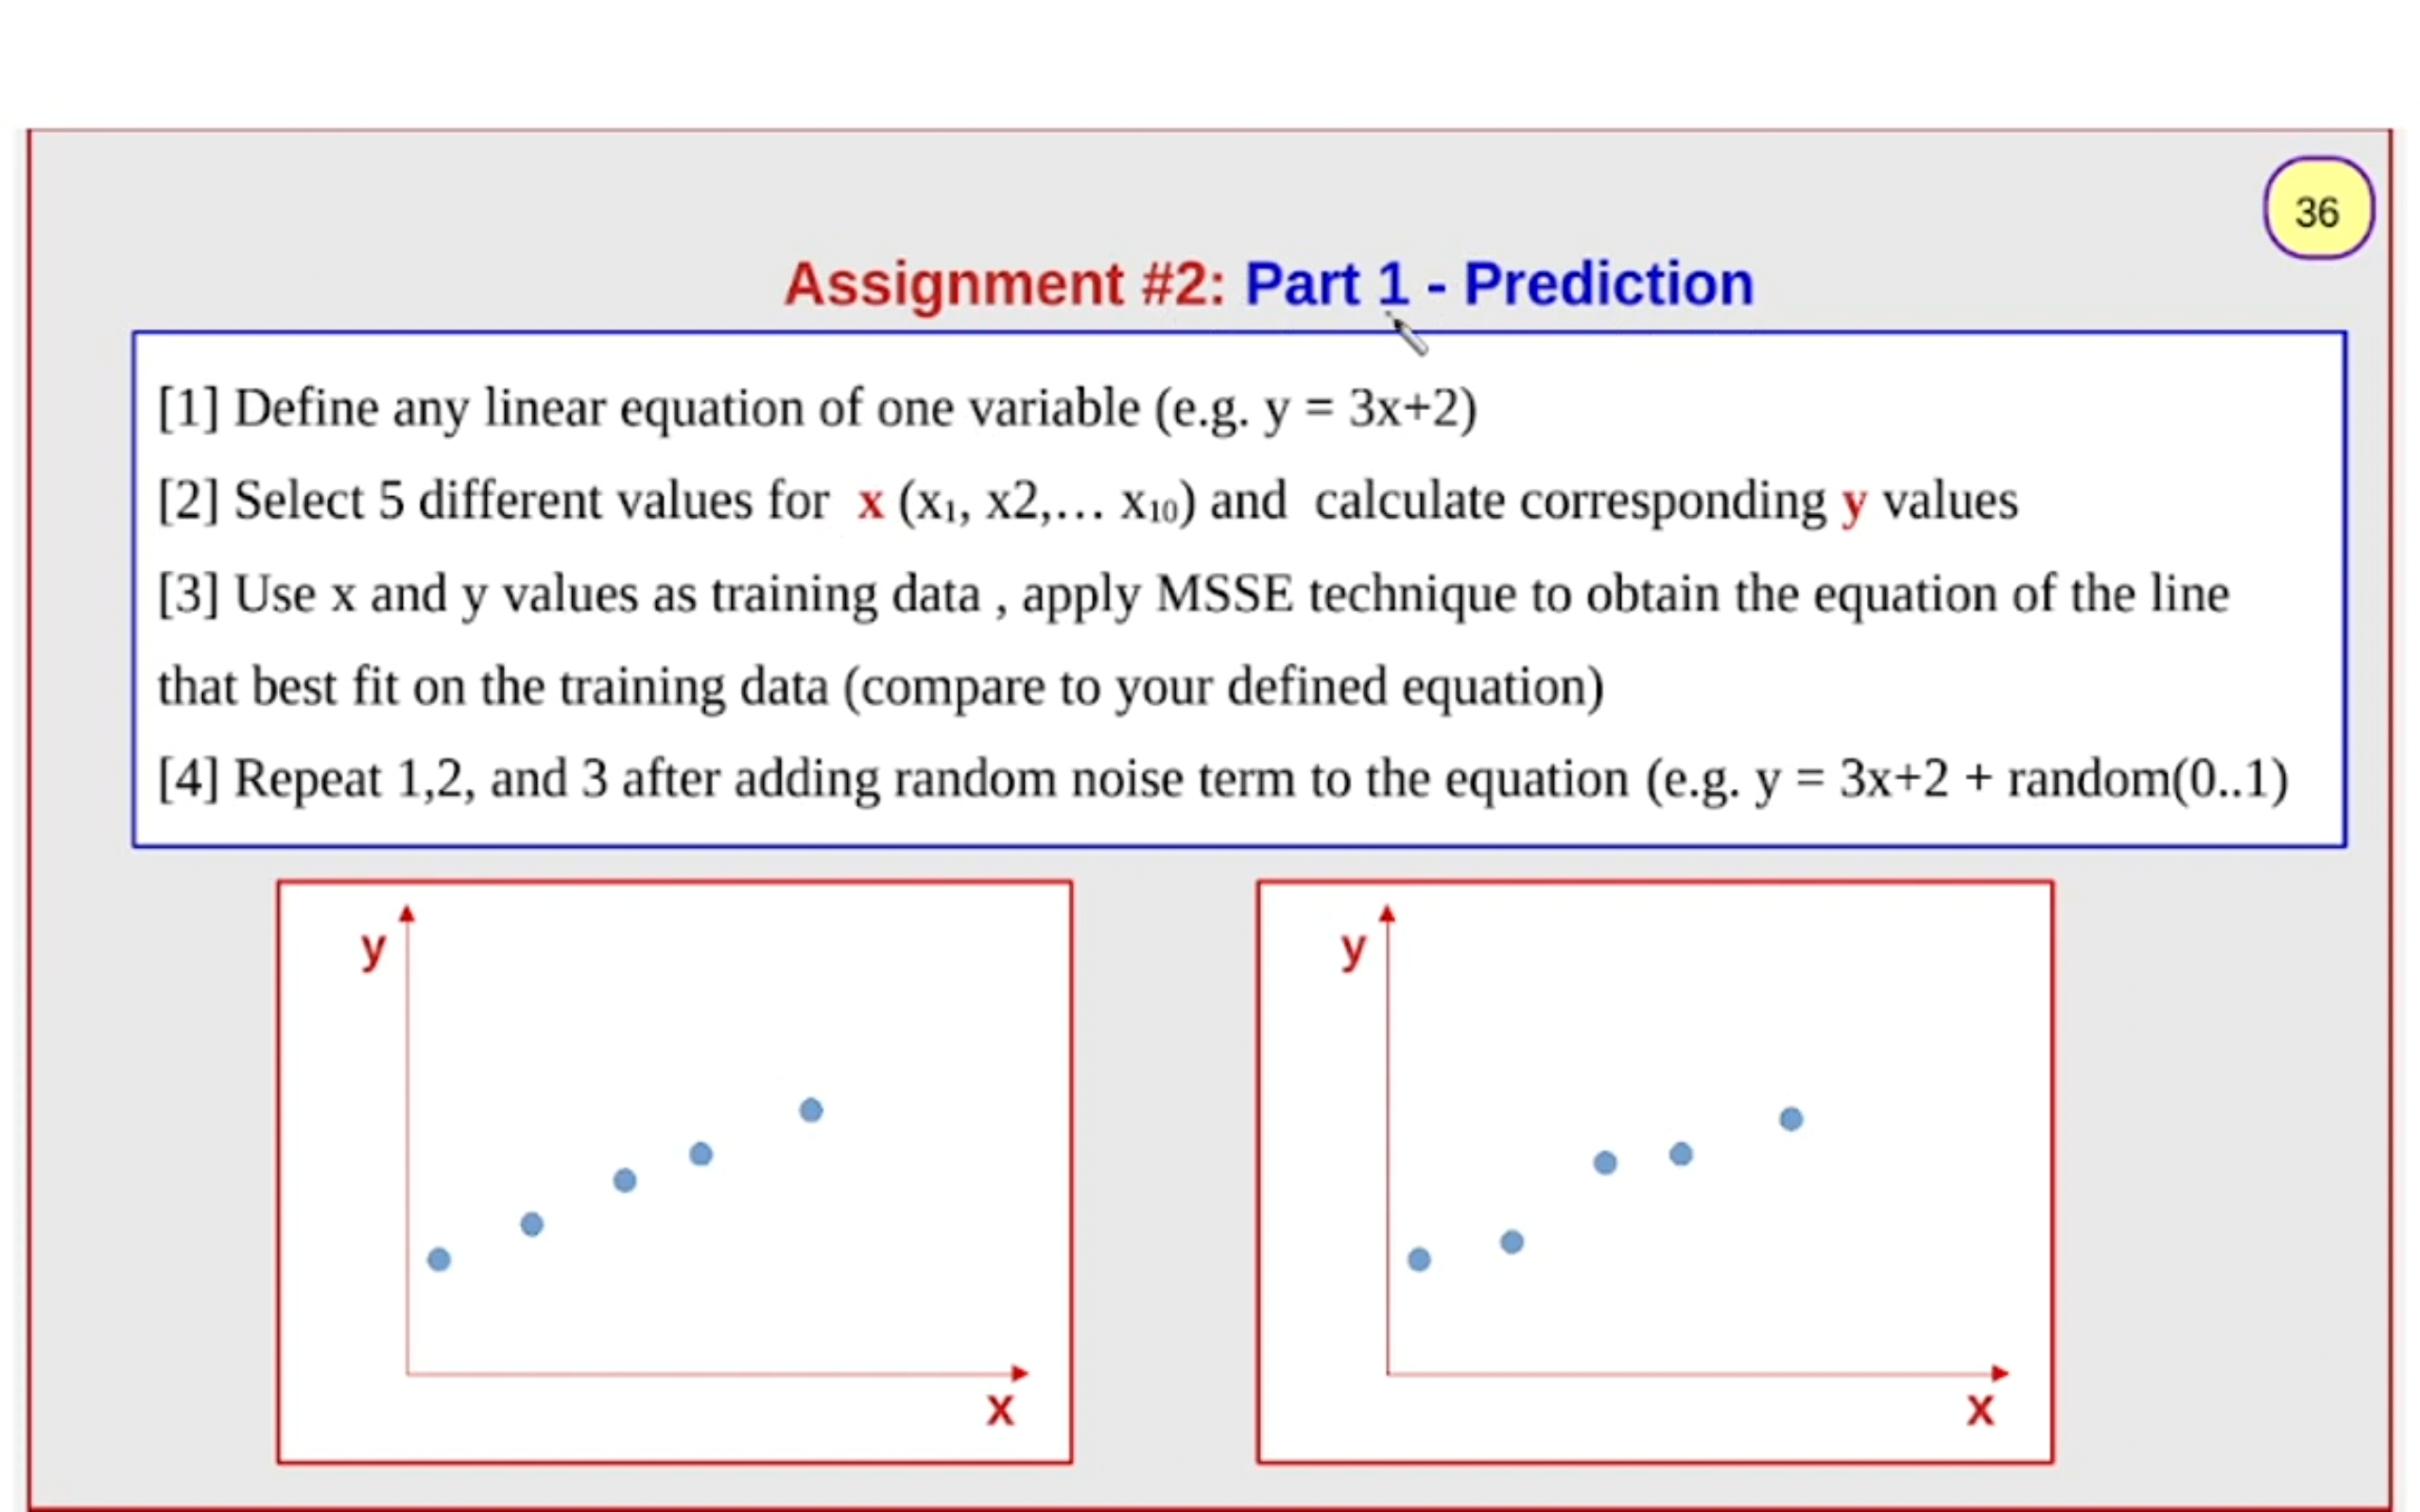
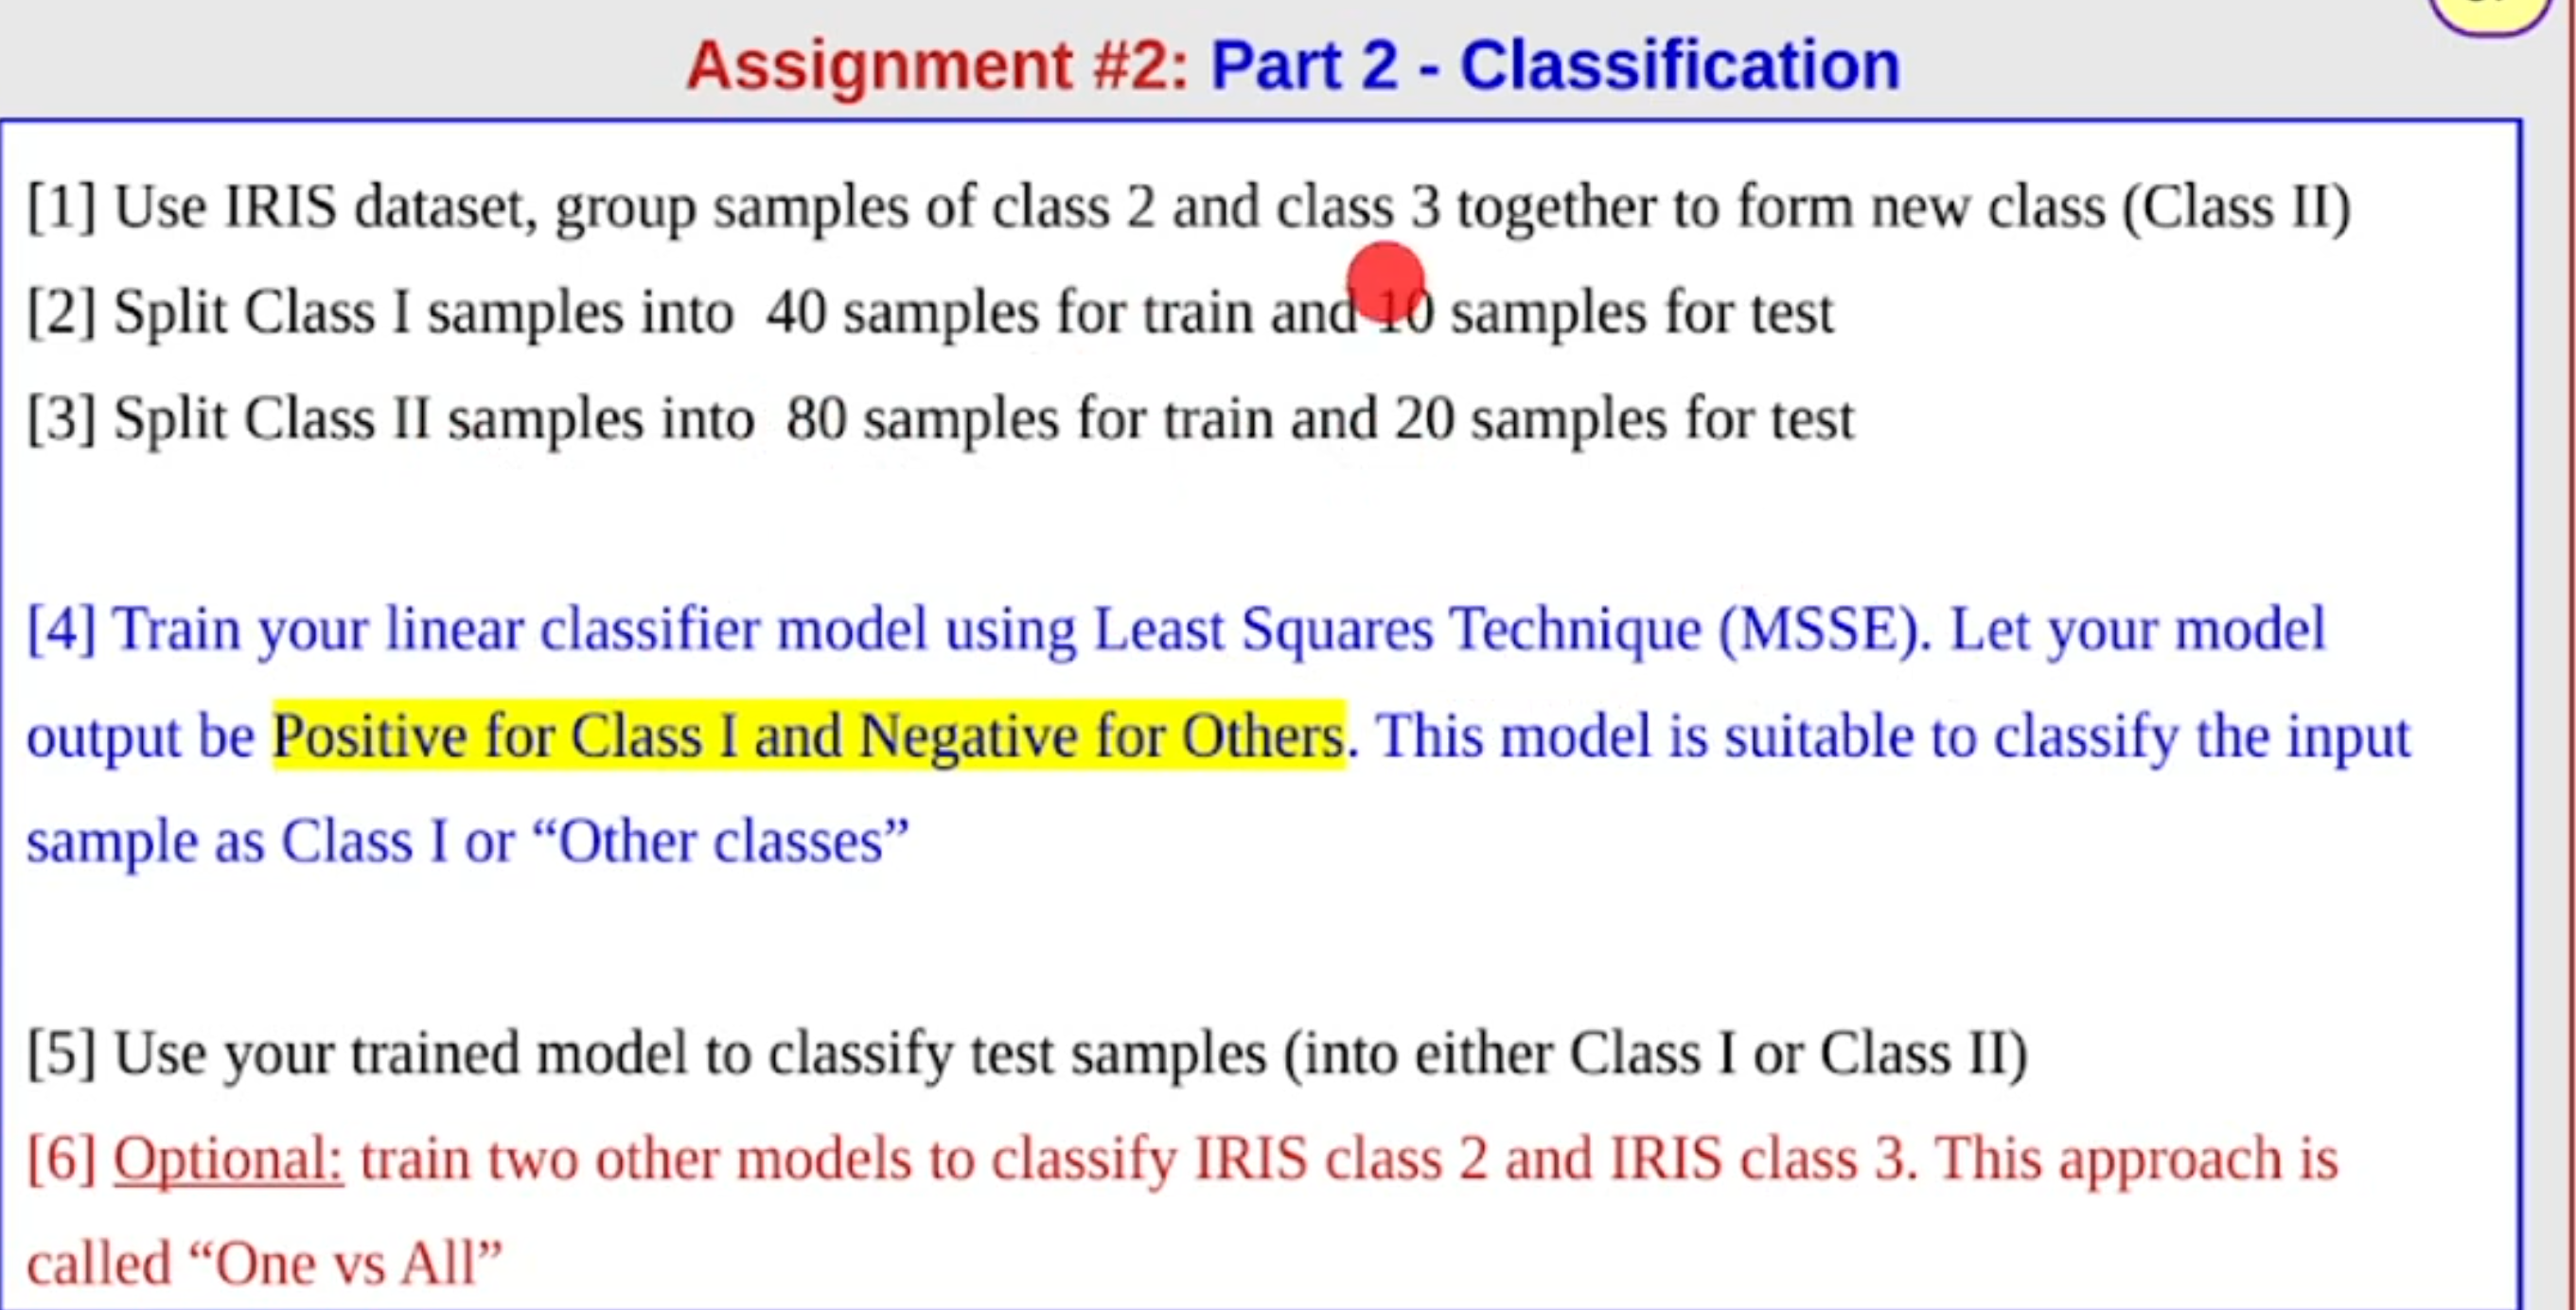

## Part 1

The chosen equation is $y=5x-1$

### Without Noise

In [196]:
import numpy as np

from linear_models import FeatureMatrix, LinearRegresser, YVector

training_data_features: FeatureMatrix = np.array(
    [
        [1],
        [2],
        [3],
        [-4],
        [-5],
    ]
)

training_data_y: YVector = np.array([4.0, 9.0, 14.0, -21.0, -26.0])

model = LinearRegresser(training_data_features, training_data_y)
model

Linear Regression model: y = -1.00 + 5.00x1

The model perfectly predicted the original equation when the error vector was $0$.

### With Noise

In [197]:
NOISE_SCALING_FACTOR = 1

noise = np.random.random_sample(training_data_y.shape) * NOISE_SCALING_FACTOR
training_data_y += noise

model = LinearRegresser(training_data_features, training_data_y)
model

Linear Regression model: y = -0.67 + 5.00x1

Random noise causes the weights to divert from their true value. This is affect is greater for greater noise scaling factors

## Part 2

### Preparing the Data

In [198]:
from pandas import read_csv

iris_data = read_csv("iris_data.csv")
iris_data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [199]:
iris_features = iris_data.drop(columns=["species"])

is_setosa = iris_data["species"] == "Iris-setosa"
is_versicolor = iris_data["species"] == "Iris-versicolor"
is_virginica = iris_data["species"] == "Iris-virginica"

is_setosa, is_versicolor, is_virginica

(0       True
 1       True
 2       True
 3       True
 4       True
        ...  
 145    False
 146    False
 147    False
 148    False
 149    False
 Name: species, Length: 150, dtype: bool,
 0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 145    False
 146    False
 147    False
 148    False
 149    False
 Name: species, Length: 150, dtype: bool,
 0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 145     True
 146     True
 147     True
 148     True
 149     True
 Name: species, Length: 150, dtype: bool)

In [200]:
from pandas import concat as concatDf

TRAINING_DATA_RATIO = 0.8

setosa_data = iris_features[is_setosa]
setosa_training_data = setosa_data.sample(frac=TRAINING_DATA_RATIO)
setosa_testing_data = setosa_data.drop(index=setosa_training_data.index)

versicolor_data = iris_features[is_versicolor]
versicolor_training_data = versicolor_data.sample(frac=TRAINING_DATA_RATIO)
versicolor_testing_data = versicolor_data.drop(index=versicolor_training_data.index)

virginica_data = iris_features[is_virginica]
virginica_training_data = virginica_data.sample(frac=TRAINING_DATA_RATIO)
virginica_testing_data = virginica_data.drop(index=virginica_training_data.index)

training_data = concatDf(
    [setosa_training_data, versicolor_training_data, virginica_training_data]
)
testing_data = concatDf(
    [setosa_testing_data, versicolor_testing_data, virginica_testing_data]
)

training_data

,sepal_length,sepal_width,petal_length,petal_width
41,4.5,2.3,1.3,0.3
34,4.9,3.1,1.5,0.1
20,5.4,3.4,1.7,0.2
49,5.0,3.3,1.4,0.2
30,4.8,3.1,1.6,0.2
...,...,...,...,...
104,6.5,3.0,5.8,2.2
117,7.7,3.8,6.7,2.2
131,7.9,3.8,6.4,2.0
108,6.7,2.5,5.8,1.8


In [201]:
is_setosa_training = is_setosa.drop(index=testing_data.index)
is_setosa_testing = is_setosa.drop(index=training_data.index)

is_versicolor_training = is_versicolor.drop(index=testing_data.index)
is_versicolor_testing = is_versicolor.drop(index=training_data.index)

is_virginica_training = is_virginica.drop(index=testing_data.index)
is_virginica_testing = is_virginica.drop(index=training_data.index)

### Training the Models

In [202]:
from pandas import Series

from linear_models import BinaryLinearClassifier


def train_iris_bin_classifier(is_species: Series[bool]) -> BinaryLinearClassifier:
    return BinaryLinearClassifier(training_data.to_numpy(), is_species.to_numpy())

In [203]:
versicolor_classifier = train_iris_bin_classifier(is_versicolor_training)
versicolor_classifier

Binary Linear Classification model: y = 2.24 + -0.04x1 + -0.92x2 + 0.42x3 + -0.94x4

In [204]:
setosa_classifier = train_iris_bin_classifier(is_setosa_training)
setosa_classifier

Binary Linear Classification model: y = -0.80 + 0.14x1 + 0.48x2 + -0.44x3 + -0.15x4

In [205]:
virginica_classifier = train_iris_bin_classifier(is_virginica_training)
virginica_classifier

Binary Linear Classification model: y = -2.44 + -0.10x1 + 0.43x2 + 0.02x3 + 1.09x4

### Testing the Models

In [206]:
from pandas import DataFrame


def test_iris_model(model: BinaryLinearClassifier, y: Series[bool]) -> float:
    predictions = model.predict(testing_data.to_numpy())
    correctness: Series[bool] = y == predictions
    return correctness.value_counts(normalize=True)[True]


DataFrame(
    {
        "Species Classifier": ["setosa", "versicolor", "virginica"],
        "Accuracy": [
            test_iris_model(setosa_classifier, is_setosa_testing),
            test_iris_model(versicolor_classifier, is_versicolor_testing),
            test_iris_model(virginica_classifier, is_virginica_testing),
        ],
    }
)

,Species Classifier,Accuracy
0,setosa,1.000000
1,versicolor,0.700000
2,virginica,0.866667


### Using _1-vs-All_ method

In [207]:
from linear_classifier import LinearClassifier

training_labels = iris_data["species"].drop(index=testing_data.index)
classifier = LinearClassifier(training_data.to_numpy(), training_labels)
classifier

Linear Classifier:
	Iris-setosa: y = -0.80 + 0.14x1 + 0.48x2 + -0.44x3 + -0.15x4
	Iris-versicolor: y = 2.24 + -0.04x1 + -0.92x2 + 0.42x3 + -0.94x4
	Iris-virginica: y = -2.44 + -0.10x1 + 0.43x2 + 0.02x3 + 1.09x4
        

In [208]:
testing_labels = iris_data["species"].loc[testing_data.index]
classifications_predictons = classifier.classify(testing_data)
accuracy = (classifications_predictons == testing_labels).value_counts(normalize=True)[
    True
]
f"Accuracy: {accuracy*100:.0f}%"

'Accuracy: 80%'